# I-ROCKET Demo: Three Bumps Dataset

The "three bumps" dataset defines three classes by placing a Gaussian bump at a distinct temporal position (t=25, 50, 75) and adding Gaussian noise. Because we know exactly where the discriminative signal is, every visualization method can be validated against ground truth.

This dataset was developed for early testing of the I-ROCKET package.

## 0. Setup

In [1]:
# Suppress OpenMP diagnostic messages that numba triggers on startup.
# These are informational only and do not affect results.
import os
os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "0"

import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
FIG_WIDTH = 8

## 1. Generate data

In [2]:
from three_bumps import generate_three_bumps

amplitudes = 3.0
sigma = 5.0
noise_std = 1.5
X, y = generate_three_bumps(n_samples=5000, amplitudes=amplitudes,
                            sigma=sigma, noise_std=noise_std, random_state=42)

print(f"Dataset: {X.shape[0]} instances x {X.shape[1]} timepoints, 3 classes")

Dataset: 5000 instances x 100 timepoints, 3 classes


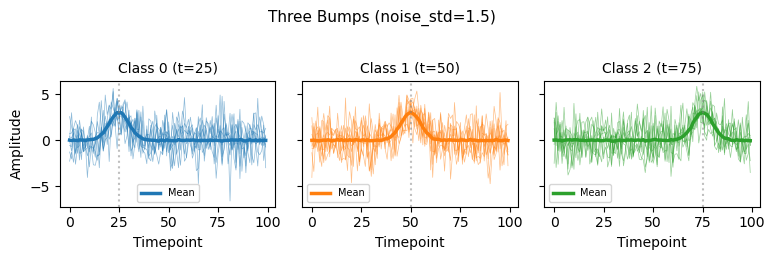

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, 2.5), sharey=True)
class_names = ["Class 0 (t=25)", "Class 1 (t=50)", "Class 2 (t=75)"]
colors = ['tab:blue', 'tab:orange', 'tab:green']

for k in range(3):
    ax = axes[k]
    mask = y == k
    for i in np.where(mask)[0][:8]:
        ax.plot(X[i], color=colors[k], alpha=0.5, linewidth=0.5)
    ax.plot(X[mask].mean(axis=0), color=colors[k], linewidth=2.5, label="Mean")
    ax.set_title(class_names[k], fontsize=10)
    ax.set_xlabel("Timepoint")
    if k == 0:
        ax.set_ylabel("Amplitude")
    ax.axvline(25 * (k + 1), color="gray", linestyle=":", alpha=0.5)
    ax.legend(fontsize=7)

fig.suptitle(f"Three Bumps (noise_std={noise_std})", fontsize=11, y=1.02)
plt.tight_layout()

## 2. Cross-validation

In [4]:
import interp_rocket_260407 as IR

results = IR.cross_validate(
    X, y,
    n_repeats=5,
    n_folds=5,
    max_dilations_per_kernel=16,
    num_features=10000,
    random_state=RANDOM_STATE,
)

print(f"\n5x5 Cross-validation results:")
for metric in ['accuracy', 'balanced_accuracy', 'mcc']:
    m = results[metric]
    print(f"  {metric:>20s}: {m['mean']:.4f} +/- {m['std']:.4f}")

Cross-validation: 5 repeats × 5 folds = 25 evaluations
  Data: 5000 instances × 100 timepoints, 3 classes
  Class counts: {np.int64(0): 1688, np.int64(1): 1650, np.int64(2): 1662}
  Repeat  1/5: acc = 0.9996  bal_acc = 0.9996  mcc = 0.9994
  Repeat  2/5: acc = 0.9994  bal_acc = 0.9994  mcc = 0.9991
  Repeat  3/5: acc = 0.9996  bal_acc = 0.9996  mcc = 0.9994
  Repeat  4/5: acc = 0.9994  bal_acc = 0.9994  mcc = 0.9991
  Repeat  5/5: acc = 0.9996  bal_acc = 0.9996  mcc = 0.9994

  Results (mean ± std across 25 folds):
    accuracy            : 0.9995 ± 0.0007
    balanced_accuracy   : 0.9995 ± 0.0007
    f1_macro            : 0.9995 ± 0.0007
    f1_weighted         : 0.9995 ± 0.0007
    mcc                 : 0.9993 ± 0.0010
    mutual_info         : 1.5802 ± 0.0069

  Aggregated confusion matrix:
            0       1       2
     0    8435       0       5
     1       5    8245       0
     2       2       0    8308

5x5 Cross-validation results:
              accuracy: 0.9995 +/- 0.0007

## 3. Feature stability analysis

InterpRocket.fit: 5000 instances × 100 timepoints
  Classes: [0 1 2]
  Fitting dilations (raw)...
  Fitting biases (raw): 2436 biases across 4 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 2436 biases across 4 dilations...
  Transforming training data...
  Feature matrix: (5000, 19488)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 1.0000
  Selected alpha: 4832.9302
CV feature stability: 5x5 folds, tracking top 50 features per fold
  Round 1/5: 70 features appeared in every round so far
  Round 2/5: 63 features appeared in every round so far
  Round 3/5: 61 features appeared in every round so far
  Round 4/5: 60 features appeared in every round so far
  Round 5/5: 60 features appeared in every round so far

  Features in ALL folds:  31
  Features in ≥80% folds: 40
  Features in NO folds:   19403
Stable features (≥80% of 25 folds): 40


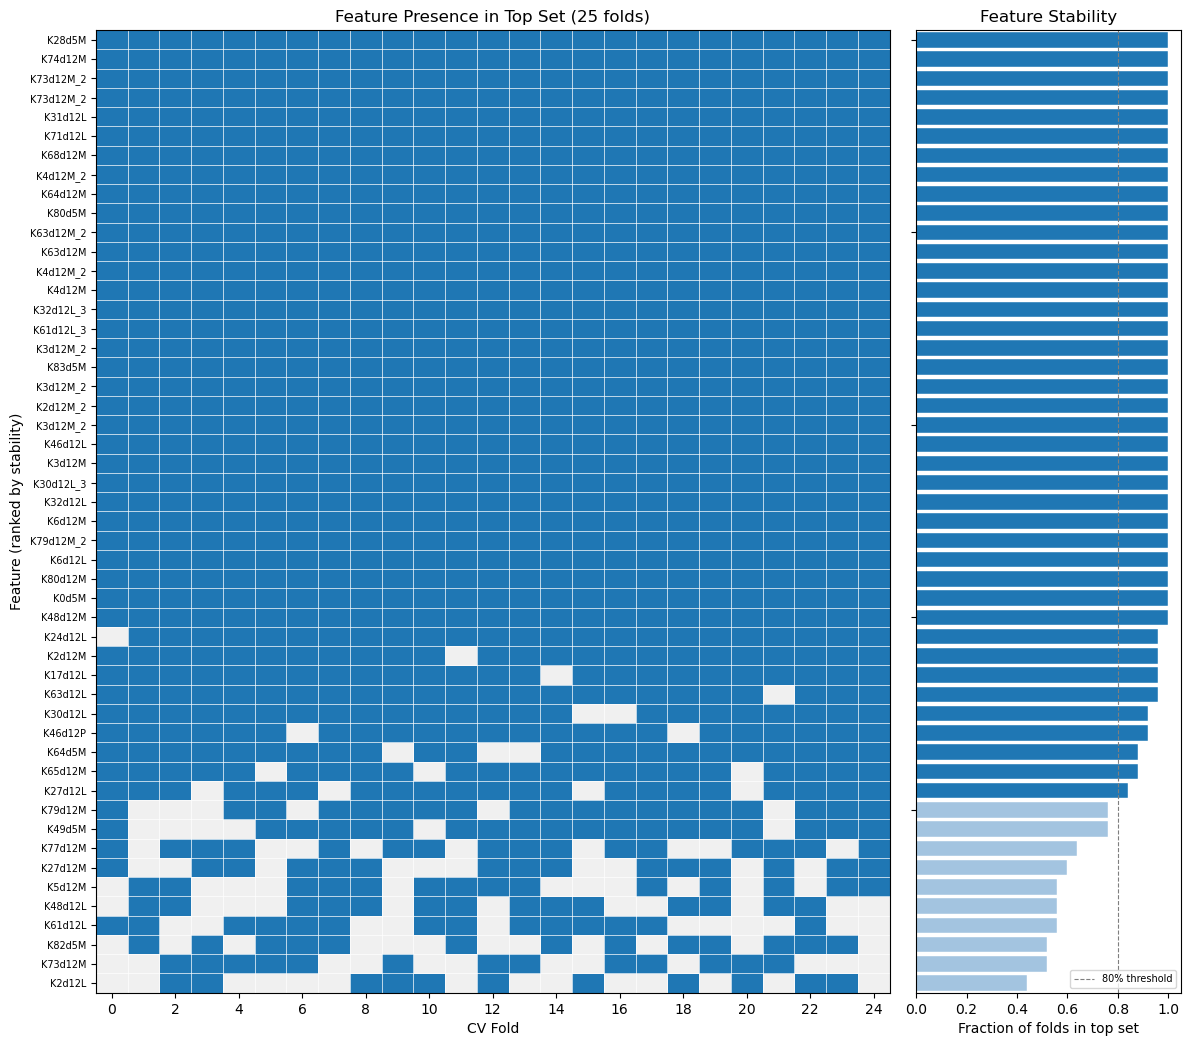

In [5]:
model = IR.InterpRocket(
    max_dilations_per_kernel=16,
    num_features=10000,
    random_state=RANDOM_STATE,
)
model.fit(X, y)

stability = IR.cv_feature_stability(X, y, n_repeats=5, n_folds=5, n_top=50)
fig = IR.plot_feature_stability(stability, model=model)

stable_features = IR.get_stable_features(stability, threshold=0.8)

### Information decomposition

In [6]:
info = IR.information_decomposition(
    model, X, y,
    group_by='kernel',
    n_shuffles=100,
    feature_mask=stable_features,
)

Information decomposition: 40 features in 25 groups (kernel)
  Ensemble MI: 1.5849 bits
  Group 2/25: I_single=0.6582, I_loo=1.5615
  Group 4/25: I_single=0.6714, I_loo=1.5656
  Group 6/25: I_single=0.0830, I_loo=1.5672
  Group 8/25: I_single=0.1791, I_loo=1.5654
  Group 10/25: I_single=0.2763, I_loo=1.5618
  Group 12/25: I_single=0.2813, I_loo=1.5594
  Group 14/25: I_single=0.6318, I_loo=1.5579
  Group 16/25: I_single=0.6978, I_loo=1.5672
  Group 18/25: I_single=0.4820, I_loo=1.5636
  Group 20/25: I_single=0.1968, I_loo=1.5636
  Group 22/25: I_single=0.6052, I_loo=1.5654
  Group 24/25: I_single=0.6124, I_loo=1.5679
  Computing null distribution (100 shuffles)...

  Results (25 groups):
    Redundant:   0 (0.0%)
    Synergistic: 0 (0.0%)
    Independent: 25 (100.0%)
    Shuffle MI:  0.2278 ± 0.3691
    Ensemble MI: 1.5849
    Sum(I_single): 11.8984
    P_ensemble (I_ens - sum(I_single)): -10.3135


## 4. Interpretability

### Stable features

In [7]:
top = model.get_top_features(feature_mask=stable_features)
for f in top:
    print(f"feature_index={f['feature_index']:>5d}  "
          f"kernel={f['kernel_index']:>2d}  d={f['dilation']:>3d}  "
          f"{f['pooling_op']:>4s}  {f['representation']:>4s}  "
          f"imp={f['importance']:.4f}")

feature_index= 9162  kernel=63  d= 12  MIPV   raw  imp=1.0000
feature_index= 7570  kernel= 6  d= 12  MIPV   raw  imp=0.9562
feature_index= 4722  kernel= 0  d=  5  MIPV   raw  imp=0.8523
feature_index= 8699  kernel=46  d= 12  LSPV   raw  imp=0.8427
feature_index= 9107  kernel=61  d= 12  LSPV   raw  imp=0.7996
feature_index= 7518  kernel= 4  d= 12  MIPV   raw  imp=0.7944
feature_index= 9446  kernel=73  d= 12  MIPV   raw  imp=0.7875
feature_index= 7486  kernel= 3  d= 12  MIPV   raw  imp=0.7750
feature_index= 8311  kernel=32  d= 12  LSPV   raw  imp=0.7742
feature_index= 8239  kernel=30  d= 12  LSPV   raw  imp=0.7633
feature_index= 7498  kernel= 3  d= 12  MIPV   raw  imp=0.7328
feature_index= 7530  kernel= 4  d= 12  MIPV   raw  imp=0.7303
feature_index= 5622  kernel=28  d=  5  MIPV   raw  imp=0.7235
feature_index= 7382  kernel=83  d=  5  MIPV   raw  imp=0.7229
feature_index= 8291  kernel=32  d= 12  LSPV   raw  imp=0.7048
feature_index= 7579  kernel= 6  d= 12  LSPV   raw  imp=0.6960
feature_

### Top kernels

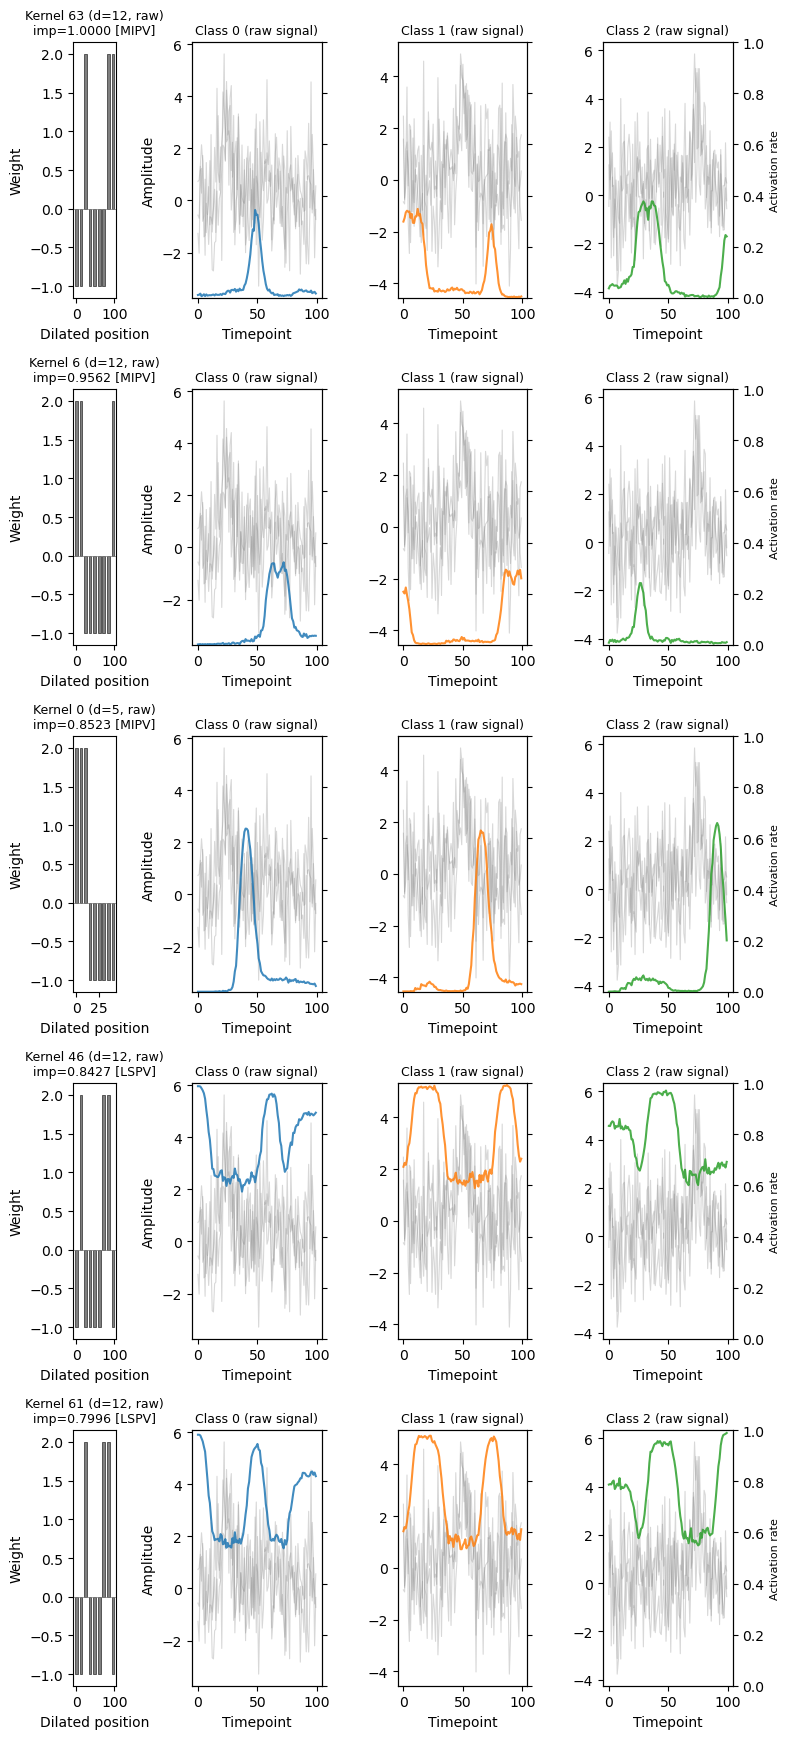

In [8]:
fig = model.plot_top_kernels(
    X, y,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 3.5 * min(5, len(stable_features))),
    n_kernels=5,
)

### Feature distributions

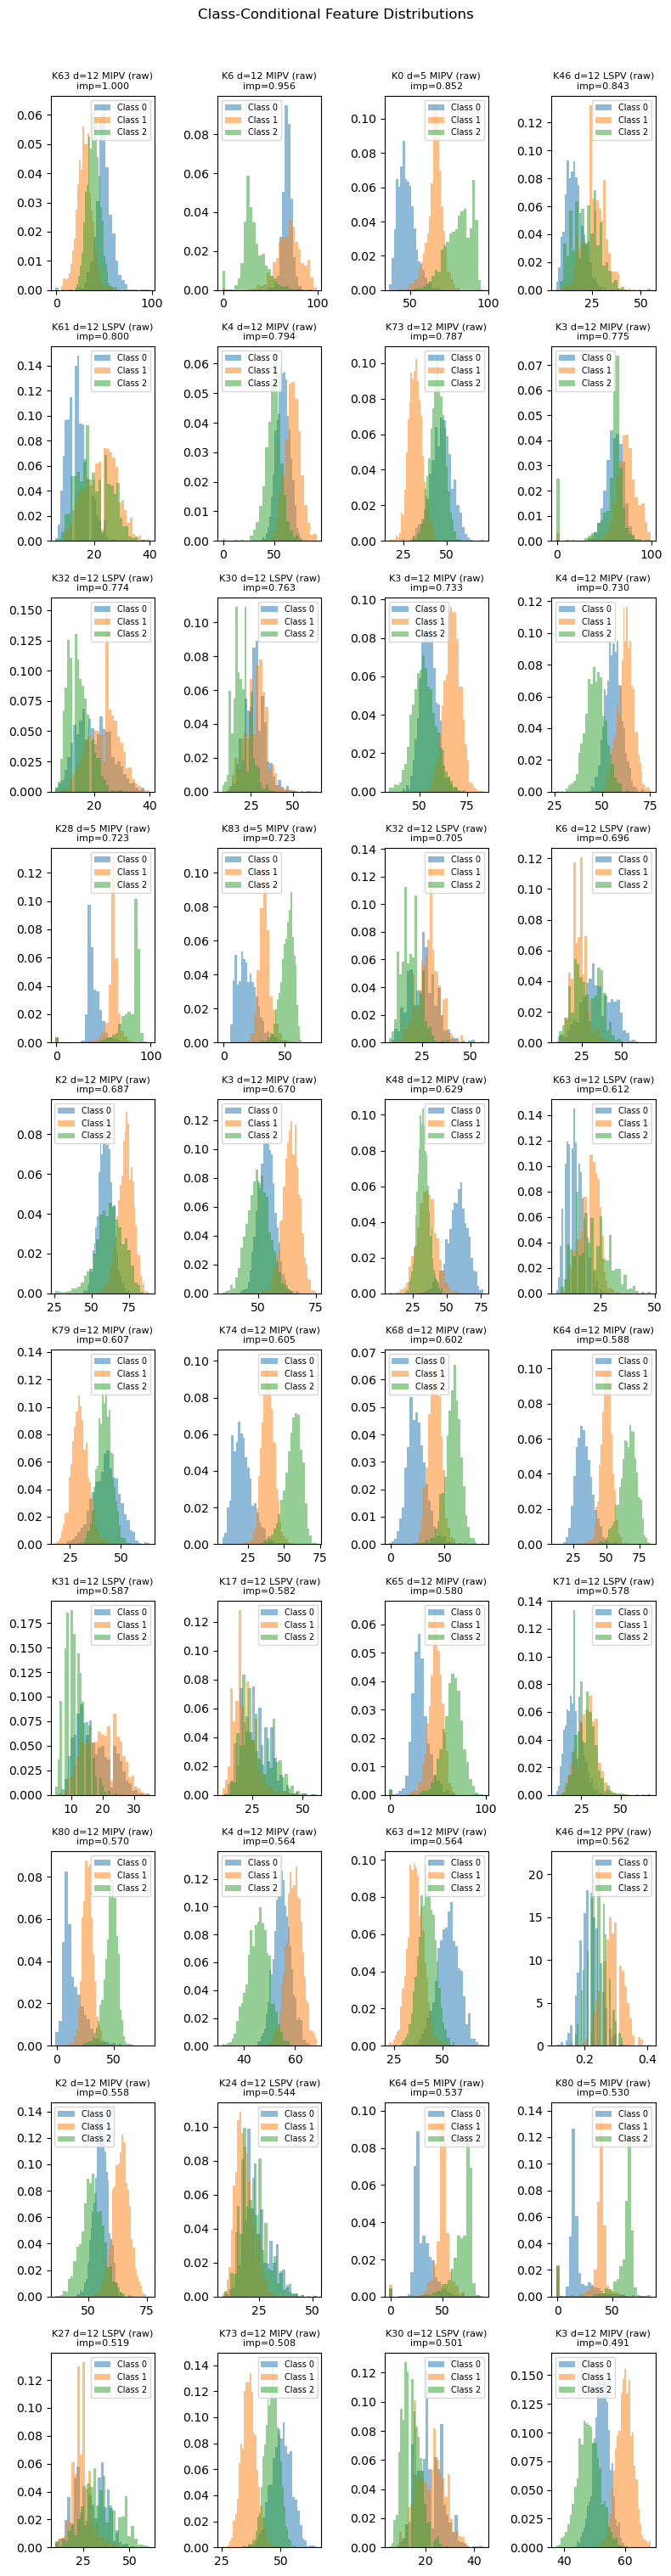

In [9]:
fig = model.plot_feature_distributions(
    X, y,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 3 * ((len(stable_features) + 3) // 4)),
)

### Kernel similarity

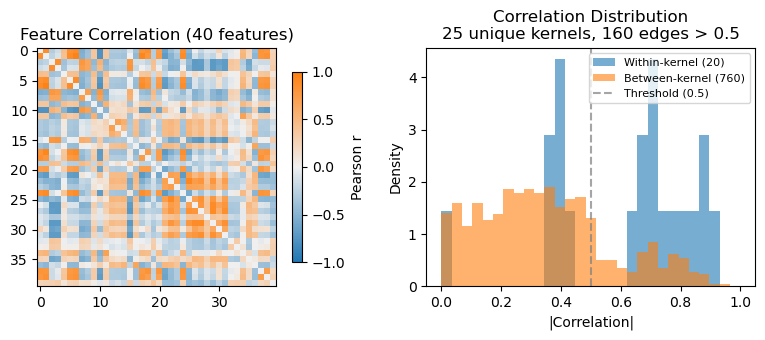

In [10]:
fig, corr = IR.plot_kernel_similarity(
    model, X,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 3.5),
)

### Temporal importance

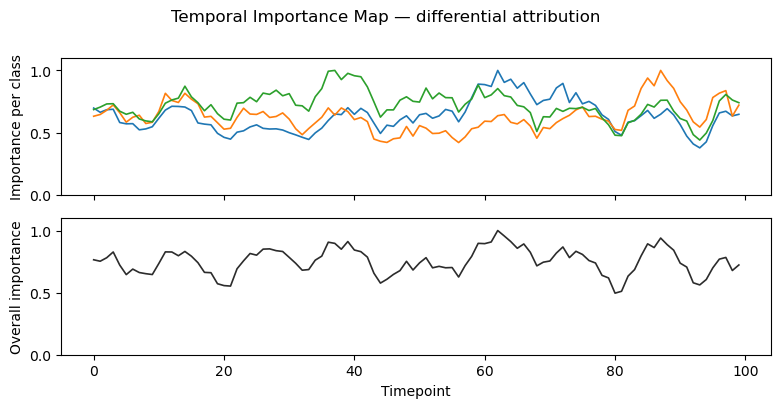

In [11]:
fig, imp_data = model.plot_temporal_importance(
    X, y, n_examples=100,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 4),
)

### Receptive field diagram

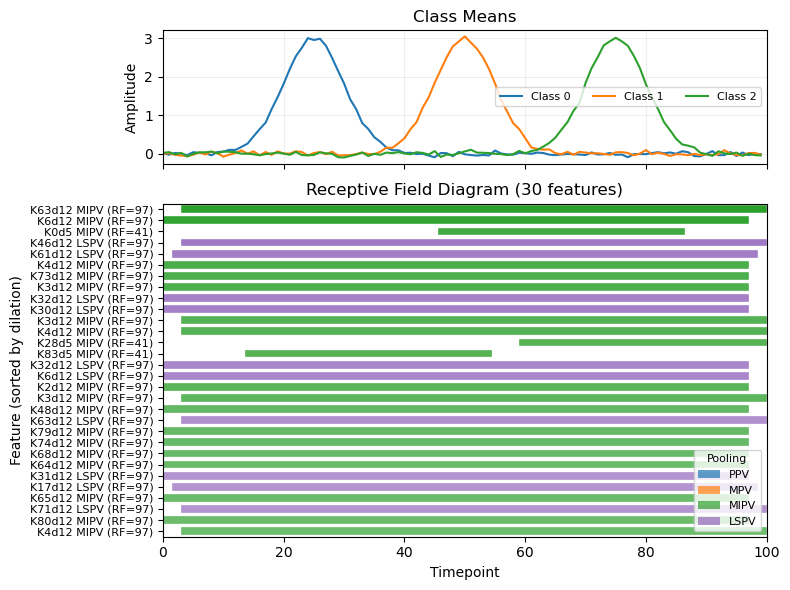

In [12]:
fig = IR.plot_receptive_field_diagram(
    model, X, y,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 6),
)

## 5. Application to class means

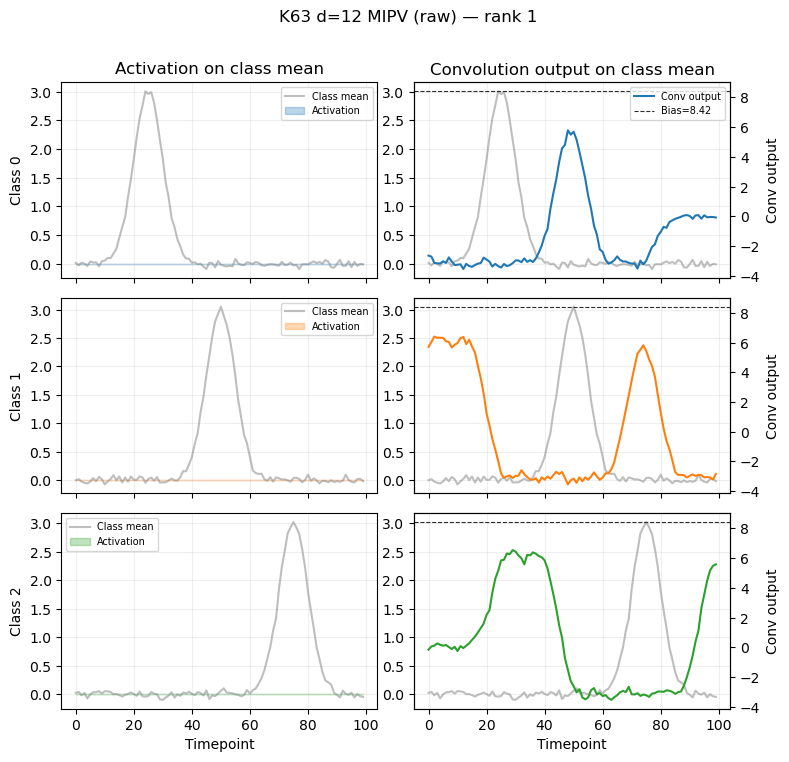

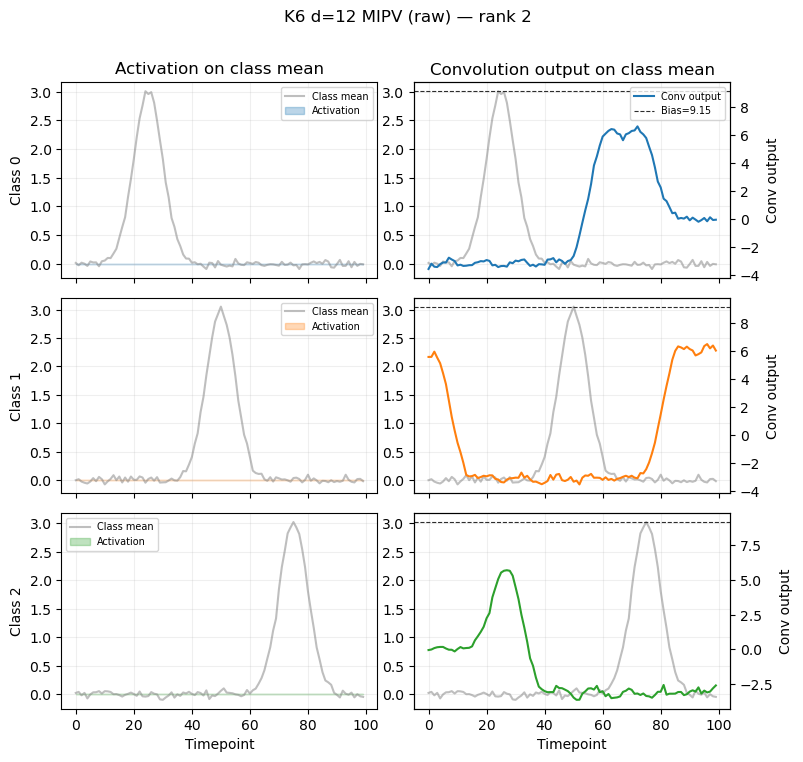

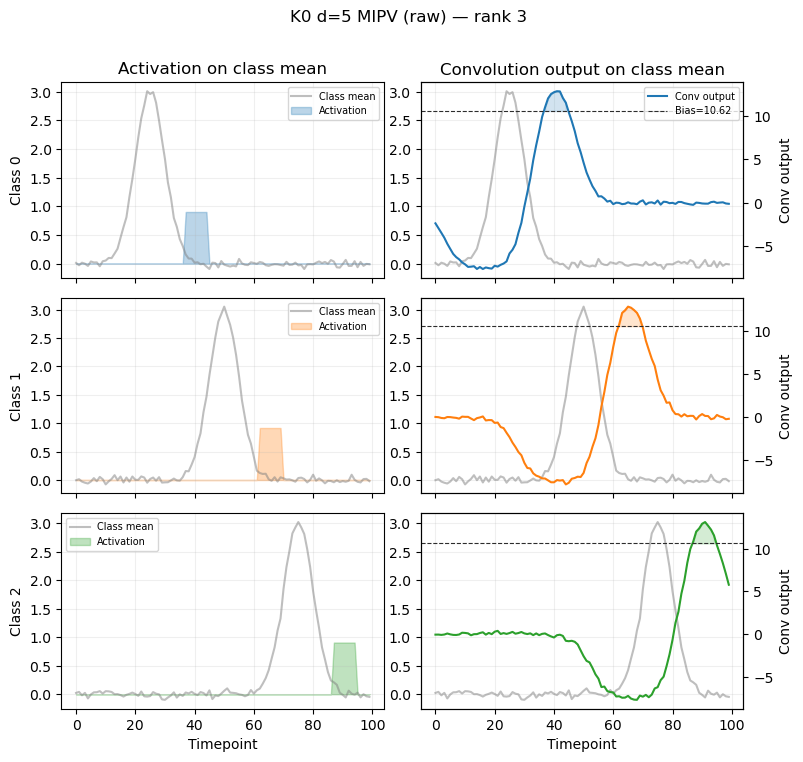

In [13]:
for rank in range(min(3, len(top))):
    fig = IR.plot_class_mean_activation(
        model, X, y,
        feature_mask=stable_features,
        feature_rank=rank,
        figsize=(FIG_WIDTH, 2.5 * len(np.unique(y))),
    )
    plt.show()

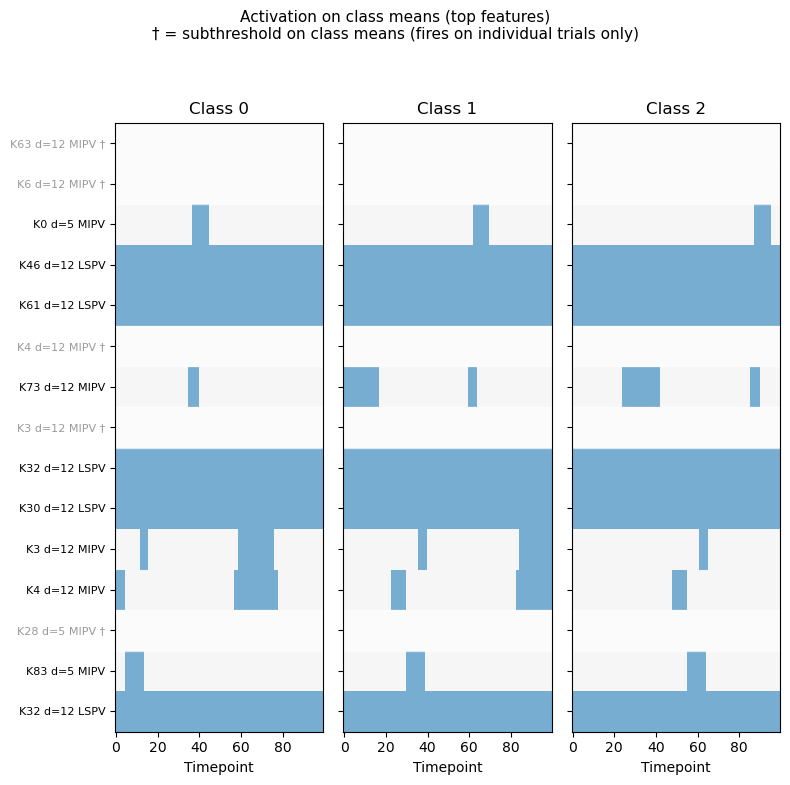

In [14]:
fig = IR.plot_multi_kernel_summary(
    model, X, y,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 0.4 * min(15, len(stable_features)) + 1.5),
)

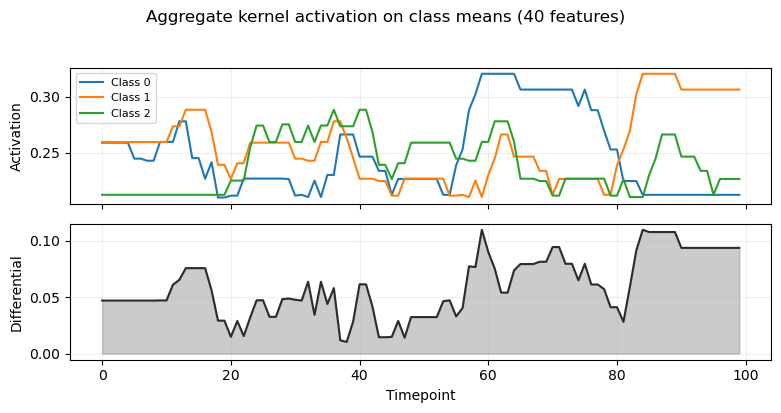

In [15]:
fig, class_act, diff = IR.plot_aggregate_activation(
    model, X, y,
    feature_mask=stable_features,
    figsize=(FIG_WIDTH, 4),
)